In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [5]:
mvirs = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [ ]:
plt.scatter(halos["GroupMass"][mask],halos["Group_M_TopHat200"][mask])

NameError: name 'mask' is not defined

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in true_divide
  """Entry point for launching an IPython kernel.


(array([15., 62., 54., 33., 16., 18., 12.,  6.,  3.,  8.,  6.,  6.,  2.,
         6.,  1.,  4.,  4.,  2.,  2.,  1.,  1.,  0.,  3.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.86777663, 0.90912616, 0.95047563, 0.99182516, 1.0331746 ,
        1.0745242 , 1.1158737 , 1.1572231 , 1.1985726 , 1.2399222 ,
        1.2812717 , 1.3226211 , 1.3639706 , 1.4053202 , 1.4466697 ,
        1.4880191 , 1.5293686 , 1.5707182 , 1.6120677 , 1.6534171 ,
        1.6947666 , 1.7361162 , 1.7774657 , 1.8188151 , 1.8601646 ,
        1.9015142 , 1.9428637 , 1.9842132 , 2.0255628 , 2.0669122 ,
        2.1082616 , 2.1496112 , 2.1909606 , 2.2323103 , 2.2736597 ,
        2.315009  , 2.3563588 , 2.3977082 , 2.4390576 , 2.4804072 ,
        2.5217566 , 2.5631063 , 2.6044557 , 2.6458051 , 2.6871548 ,
        2.7285042 , 2.7698536 , 2.8112032 , 2.8525527 , 2.8939023 ,
        2.9352517 ], dtype=float32),

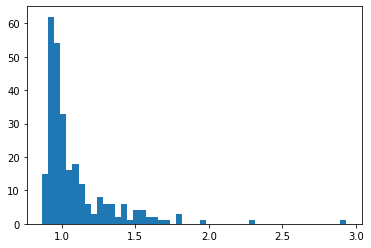

In [ ]:
plt.hist((halos["GroupMass"]/halos["Group_M_TopHat200"])[mask], bins=50)



In [6]:
mask = (mvirs > 13) & (mvirs < 13.1)

In [7]:
pos = halos["GroupPos"][mask]/1e3

In [8]:
nhalo = len(pos)
print(nhalo)

268


In [9]:
from random import randint

In [11]:
from NFWdist import *
ngal1 = 10
ngal2 = 10
con1 = 4
con2 = 4
r_list = []
rvir1 = 0.5
rvir2 = 0.5
w1 = 1
w2 = 10

odir = f"toy_models/weighted_c4_rvir0.5_n{ngal1}"
#fname = f"{odir}/nfw_sat_pos_c{con1}_c{con2}_rvir{rvir1}_rvir{rvir2}_n{ngal1}.txt"
fname = f"{odir}/nfw_sat_pos_w{w2}_w20_in_rs.txt"
random.seed(0)
#with open(f"{odir}/nfw_sat_sum_pos_n{ngal1}_n{ngal2}.txt", "w") as fsum:
weight_list = [w1]*int(ngal1/2) + [w2]*int(ngal1/2)

with open(f"{odir}/nfw_sat_sum_pos_w{w2}_w20_in_rs.txt", "w") as fsum:
    with open(fname, "w") as f:
        for ihalo in range(nhalo):
            #k = randint(0,1)
            k=0
            
            if k == 0:
                ngal = ngal1
                r_values = rnfw(ngal,con=con1)
                rvir = rvir1
                
                
            else:
                ngal = ngal2
                #r_values = rnfw(ngal,con=con2)
                r_values = rnfw(ngal,con=con1)

                theta = np.arccos(2 * np.random.rand(ngal2) - 1)
                phi = 2 * np.pi * np.random.rand(ngal2)
                rvir=rvir2
        
            

            r_values *= rvir
            theta = np.arccos(2 * np.random.rand(ngal) - 1)
            phi = 2 * np.pi * np.random.rand(ngal)
                
                
            x = r_values * np.sin(theta) * np.cos(phi)
            y = r_values * np.sin(theta) * np.sin(phi)
            z = r_values * np.cos(theta)
            weight_tot = 0
            for igal in range(ngal):
                rand =  randint(0,1)
                #rand = 0
                if r_values[igal] < rvir/con1:
                    if rand == 0:
                        #weight = np.random.normal(loc=w2, scale=0.5)
                        weight = w2
                    elif rand == 1:
                        #weight = np.random.normal(loc=4, scale=0.5)
                        weight = 20
                
                else:
                    weight = 1
                weight_tot += weight
                print(1, 13, pos[:,0][ihalo] + x[igal], pos[:,1][ihalo] + y[igal], pos[:,2][ihalo] + z[igal], weight, file=f)
                #print(1, 13, x[igal], y[igal], z[igal], weight, file=f)
            
            
            print(1, 13, pos[:,0][ihalo], pos[:,1][ihalo], pos[:,2][ihalo], weight_tot, file=fsum)

In [ ]:
# with open("nfw_sat_sum_pos_n200.txt", "w") as f:
#     for ihalo in range(nhalo):            
#         print(1, 13, pos[:,0][ihalo], pos[:,1][ihalo], pos[:,2][ihalo], 200, file=f)